In [1]:
# import key libraries and kernel settings
import os
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [419]:
# first we need to loop through each target x water speed csv and convert them from wide to long format.
def load_solutions_convert_to_long_format(
                                  file_path_list=["C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_L60.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_L30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_R30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_R60.csv",
                                                  
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_L60.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_L30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_R30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_R60.csv"]):
    # initialize df
    combined_df = pd.DataFrame()

    for file in file_path_list:

        # extract current water speed vals
        current_speed = int(file[-10:-8])
        current_target = file[-7:-4]
        
        # read csv per file loop
        df_wide = pd.read_csv(file)

        # change name of df_tmp 'unnamed' column
        df_wide.rename(columns={'Unnamed: 0': 'speed'}, inplace=True)

        # convert to long format
        df_long = df_wide.melt(
            id_vars=['speed'],
            var_name = 'angle',
            value_name = 'error_m'
        )

        # make new column called error_cm
        df_long['error_cm'] = df_long['error_m'] * 100

        # add new columns for current speed & target
        df_long['water_speed'] = current_speed
        df_long['target_id'] = current_target

        # ensure launch angle is a float
        df_long['angle'] = pd.to_numeric(df_long['angle'])
        
        # make boolean variable that labels which launch parameter combinations result in errors below 8.75 cm (based on ball of r = 5.0 cm and target of r = 3.75 cm)
        df_long['is_hit'] = df_long['error_cm'] < 8.75
        
        # make df with ONLY hits since we are comparing the participant's executed launches to the NEAREST valid launch solutions
        df_hits = df_long[df_long['is_hit'] == True].copy()

        # append df_long to a combined df
        combined_df = pd.concat([combined_df, df_hits], ignore_index=True)

    return combined_df
        

In [421]:
solutions_df = load_solutions_convert_to_long_format()
solutions_df

,speed,angle,error_m,error_cm,water_speed,target_id,is_hit
0,7.65,11.0,0.086649,8.664939,-2,L60,True
1,7.70,11.0,0.082720,8.271994,-2,L60,True
2,6.95,11.5,0.083945,8.394546,-2,L60,True
3,7.00,11.5,0.079482,7.948160,-2,L60,True
4,7.05,11.5,0.076267,7.626703,-2,L60,True
...,...,...,...,...,...,...,...
19813,7.90,64.5,0.073845,7.384503,-3,R60,True
19814,7.95,64.5,0.072870,7.286959,-3,R60,True
19815,8.00,64.5,0.069388,6.938780,-3,R60,True
19816,7.95,65.0,0.084747,8.474675,-3,R60,True


In [631]:
# make function to run and extract mahalanobis-like distance from nearest launch solution in manifold

def load_raw_data_extract_sd_vectors(file_name="C:/Users/jacob/water_current_MA/data/solution_space/df_raw.csv",
                                     phases_to_keep=['training_1','training_2']):

    # load file
    df = pd.read_csv(file_name)[['ppid_full','trial_num','phase','target_x_label','speed_label','launch_Speed','launch_angle']]

    # filter df so it ONLY contains phases_to_keep
    df_phases = df[df['phase'].isin(phases_to_keep)].copy()

    # extract current water speeds and targets
    water_speeds_str = np.unique(df_phases['speed_label'])
    water_speeds = water_speeds_str.astype(int)
    targets = np.unique(df_phases['target_x_label'])

    # initialize dictionary to store vectors
    launch_vectors = {}
    
    for target in targets:
        for water_speed in water_speeds:
            for phase in phases_to_keep:
    
                # print("TARGET = ", target)
                # print("WATER SPEED =", water_speed)
                
                # filter df so it only contains current target & water speed
                df_filtered = df_phases[(df_phases['target_x_label'] == target) & (df_phases['speed_label'] == water_speed)]
    
                # extract launch speed & angle vector
                raw_launch_speeds = df_filtered['launch_Speed'].values
                raw_launch_angles = df_filtered['launch_angle'].values
    
                # initialize tuple key and store in dictionary
                key = (target, water_speed, phase)
                if key not in launch_vectors:
                    launch_vectors[key] = {}
    
                    # add vector of launch speeds & angles per key to dictionary
                    launch_vectors[key]['launch_speeds'] = raw_launch_speeds
                    launch_vectors[key]['launch_angles'] = raw_launch_angles
                        
                    speed_std = df_filtered[df_filtered['phase'] == phase]['launch_Speed'].std()
                    launch_vectors[key]['speed_std'] = speed_std
                    
                    angle_std = df_filtered[df_filtered['phase'] == phase]['launch_angle'].std()
                    launch_vectors[key]['angle_std'] = angle_std

    # returns dictionary
    return launch_vectors,  df_phases[['ppid_full', 'phase', 'trial_num', 'target_x_label', 'speed_label']]
            

In [633]:
tmp, df_phases = load_raw_data_extract_sd_vectors()
tmp

# keys = tmp.keys()

# for key in keys:
#     print(key)

# for key, value in tmp.items():
#     print(key)

#     print(value['phase'])

{('L30',
  -3,
  'training_1'): {'launch_speeds': array([2.923085, 4.036107, 3.141253, ..., 3.243121, 2.685901, 2.70252 ]), 'launch_angles': array([33.77943, 50.93708, 35.73315, ..., 72.75337, 67.82315, 49.64223]), 'speed_std': 0.6864073092836777, 'angle_std': 17.05428334740732},
 ('L30',
  -3,
  'training_2'): {'launch_speeds': array([2.923085, 4.036107, 3.141253, ..., 3.243121, 2.685901, 2.70252 ]), 'launch_angles': array([33.77943, 50.93708, 35.73315, ..., 72.75337, 67.82315, 49.64223]), 'speed_std': 0.5369499804602466, 'angle_std': 14.226504631394056},
 ('L30',
  -2,
  'training_1'): {'launch_speeds': array([4.960846, 3.86094 , 3.594671, ..., 1.424058, 1.898972, 1.889224]), 'launch_angles': array([ 89.60324, 108.1371 ,  97.66446, ...,  43.35823,  51.31053,
          48.78172]), 'speed_std': 0.5105900475733143, 'angle_std': 19.240646157139704},
 ('L30',
  -2,
  'training_2'): {'launch_speeds': array([4.960846, 3.86094 , 3.594671, ..., 1.424058, 1.898972, 1.889224]), 'launch_angles':

In [731]:
df_phases

,ppid_full,phase,trial_num,target_x_label,speed_label
0,p000_neg2,training_1,53,R30,-2.0
1,p000_neg2,training_1,54,L60,-2.0
2,p000_neg2,training_1,55,R30,-2.0
3,p000_neg2,training_1,56,L60,-2.0
4,p000_neg2,training_1,57,R30,-2.0
...,...,...,...,...,...
26045,p050_neg3,training_2,420,R30,-3.0
26046,p050_neg3,training_2,421,R30,-3.0
26047,p050_neg3,training_2,422,L60,-3.0
26048,p050_neg3,training_2,423,L60,-3.0


In [729]:
def run_mahalanobis_like(raw_dictionary, solution_df):

    # input solution / hit parameter vectors

    min_d_vals = []

    # grab raw data dictionaries
    for key, value in raw_dictionary.items():
        
        target = key[0]
        water_speed = key[1]
        phase = key[2]

        print(water_speed, target, phase)

        speeds_std = value['speed_std']
        angle_std = value['angle_std']
        
        real_speeds = value['launch_speeds']
        real_angles = value['launch_angles']

        solutions_filtered = solution_df[(solution_df['target_id'] == target) & (solution_df['water_speed'] == water_speed)]

        # broadcast and find differences, then normalize by variability of each parameter
        speed_diffs = (real_speeds[:, np.newaxis] - solutions_filtered['speed'].values[np.newaxis, :]) / speed_std
        theta_diffs = (real_angles[:, np.newaxis] - solutions_filtered['angle'].values[np.newaxis, :]) / theta_std
        
        d = np.sqrt((speed_diffs**2) + (theta_diffs**2))
        min_d = np.min(d, axis=1)
        print("length of min_d:", len(min_d))

        min_d_vals.append(min_d)

    min_d = np.concatenate(min_d_vals)

    return min_d
    
    
    

In [725]:
t = run_mahalanobis_like(tmp, solutions_df)




-3 L30 training_1
length of min_d: 3336
-3 L30 training_2
length of min_d: 3336
-2 L30 training_1
length of min_d: 3209
-2 L30 training_2
length of min_d: 3209
-3 L60 training_1
length of min_d: 3350
-3 L60 training_2
length of min_d: 3350
-2 L60 training_1
length of min_d: 3199
-2 L60 training_2
length of min_d: 3199
-3 R30 training_1
length of min_d: 3268
-3 R30 training_2
length of min_d: 3268
-2 R30 training_1
length of min_d: 3202
-2 R30 training_2
length of min_d: 3202
-3 R60 training_1
length of min_d: 3283
-3 R60 training_2
length of min_d: 3283
-2 R60 training_1
length of min_d: 3203
-2 R60 training_2
length of min_d: 3203


In [727]:
t

array([[       nan,        nan, 0.09127971],
       [       nan,        nan, 0.56346916],
       [       nan,        nan, 0.00872635],
       ...,
       [       nan,        nan, 0.0021697 ],
       [       nan,        nan, 0.1503585 ],
       [       nan,        nan, 0.05919661]])

hit min None
hit max None


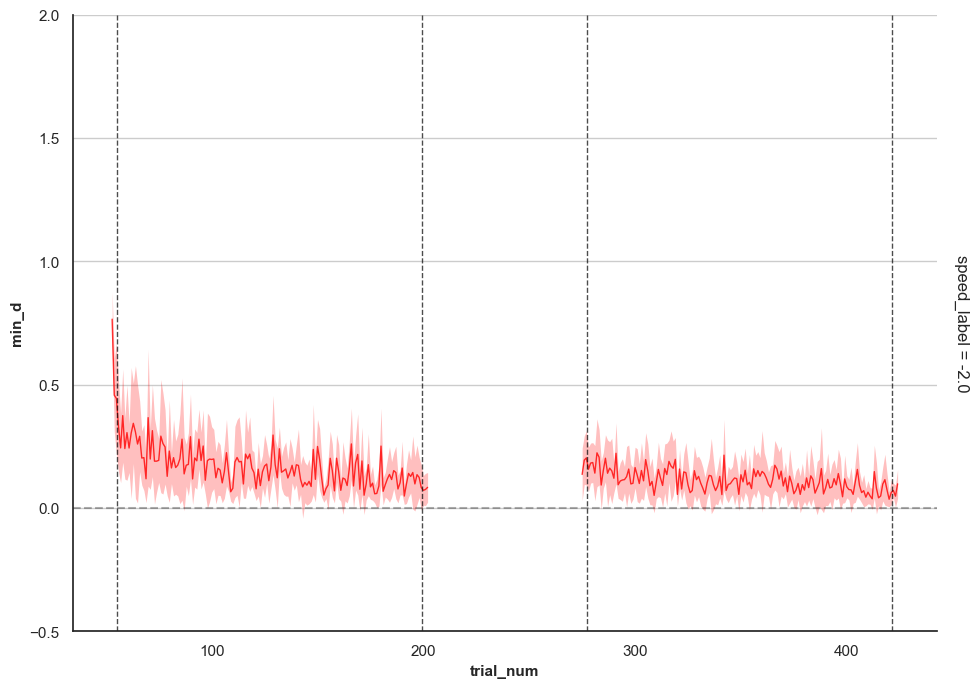

In [657]:
from src.plotting import plot_all_trials

plot_all_trials(t, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'min_d', # 
                     x_col='trial_num',
                     vertical_list=[55.5,199.5, 277.5,421.5],
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col=None,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-0.5,2),
                     show_zero_line=True
                    )                    

In [53]:
# import in subset df_L60_3_T1
df_participant = pd.read_csv("C:/Users/jacob/water_current_MA/data/solution_space/df_L60_3_T1.csv")
df_participant.columns

speeds_std = df_participant['launch_Speed'].std()
theta_std = df_participant['launch_angle'].std()


In [55]:

# make hit and real speeds into np.array
hit_speeds = df_hits['speed'].values
real_speeds = df_participant['launch_Speed'].values

# make hit and real angles into np.array
hit_thetas = df_hits['angle'].values
real_thetas = df_participant['launch_angle'].values

# broadcast and find differences, then normalize by variability of each parameter
speed_diffs = (real_speeds[:, np.newaxis] - hit_speeds[np.newaxis, :]) / speeds_std
theta_diffs = (real_thetas[:, np.newaxis] - hit_thetas[np.newaxis, :]) / theta_std

d = np.sqrt((speed_diffs**2) + (theta_diffs**2))
min_d = np.min(d, axis=1)




In [381]:
d.shape

(1485, 3361)

In [57]:
# now take min_d array and make it a column in df_participant for plotting
df_participant['min_d'] = min_d
df_participant

,Unnamed: 0,experiment,ppid_full,speed_label,target_x_label,target_position_x_cm,target_position_z_cm,trial_num,phase,phase_trial_num,...,is_outlier,launch_deviation_mean,launch_deviation_median,flip_min_distance_xPCA_mean,flip_min_distance_xPCA_median,launch_deviation_mean_bc,launch_deviation_median_bc,flip_min_distance_xPCA_mean_bc,flip_min_distance_xPCA_median_bc,min_d
0,20303,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,53,training_1,1,...,False,0.153491,1.766991,-6.070105,-10.584746,2.752700,1.13920,67.908700,72.423341,2.189217
1,20304,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,55,training_1,3,...,False,0.153491,1.766991,-6.070105,-10.584746,68.679630,67.06613,18.885337,23.399978,0.276597
2,20307,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,58,training_1,6,...,False,0.153491,1.766991,-6.070105,-10.584746,76.740860,75.12736,-3.164352,1.350289,0.025923
3,20309,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,60,training_1,8,...,False,0.153491,1.766991,-6.070105,-10.584746,63.567300,61.95380,-24.497774,-19.983133,0.553259
4,20310,S1_3.0M-projectile_experiment 1,1_neg3,-3.0,L60,-60.0,140.0,61,training_1,9,...,False,0.153491,1.766991,-6.070105,-10.584746,71.018780,69.40528,-17.120169,-12.605528,0.256682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,40011,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,193,training_1,141,...,False,-1.594872,-2.112009,0.297211,3.268425,38.031663,38.54880,7.786019,4.814805,0.178990
1481,40014,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,196,training_1,144,...,False,-1.594872,-2.112009,0.297211,3.268425,47.705363,48.22250,-11.958068,-14.929283,0.023386
1482,40015,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,197,training_1,145,...,False,-1.594872,-2.112009,0.297211,3.268425,38.688183,39.20532,-16.187316,-19.158530,0.076840
1483,40017,S1_3.0M-projectile_experiment 1,p048_neg3,-3.0,L60,-60.0,140.0,199,training_1,147,...,False,-1.594872,-2.112009,0.297211,3.268425,38.880773,39.39791,9.678422,6.707207,0.022503


hit min None
hit max None


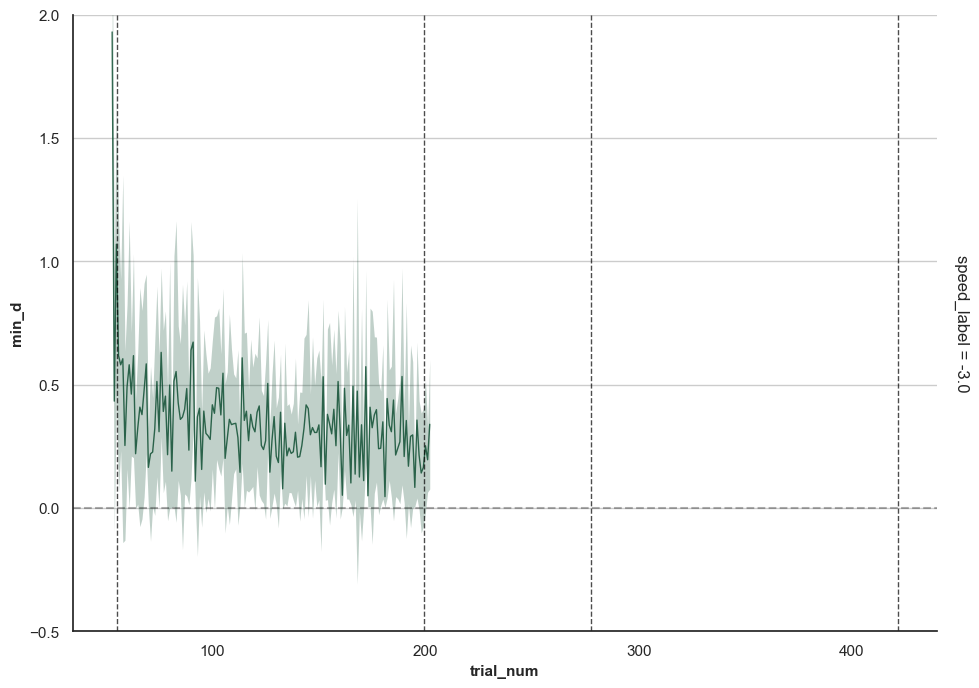

In [373]:
from src.plotting import plot_all_trials

plot_all_trials(df_participant, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'min_d', # 
                     x_col='trial_num',
                     vertical_list=[55.5,199.5, 277.5,421.5],
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col=None,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-0.5,2),
                     show_zero_line=True
                    )                    

Length of real speeds: 1485
Length of hit speeds: 3361
Length of real thetas: 1485
Length of hit thetas: 3361
hit min None
hit max None


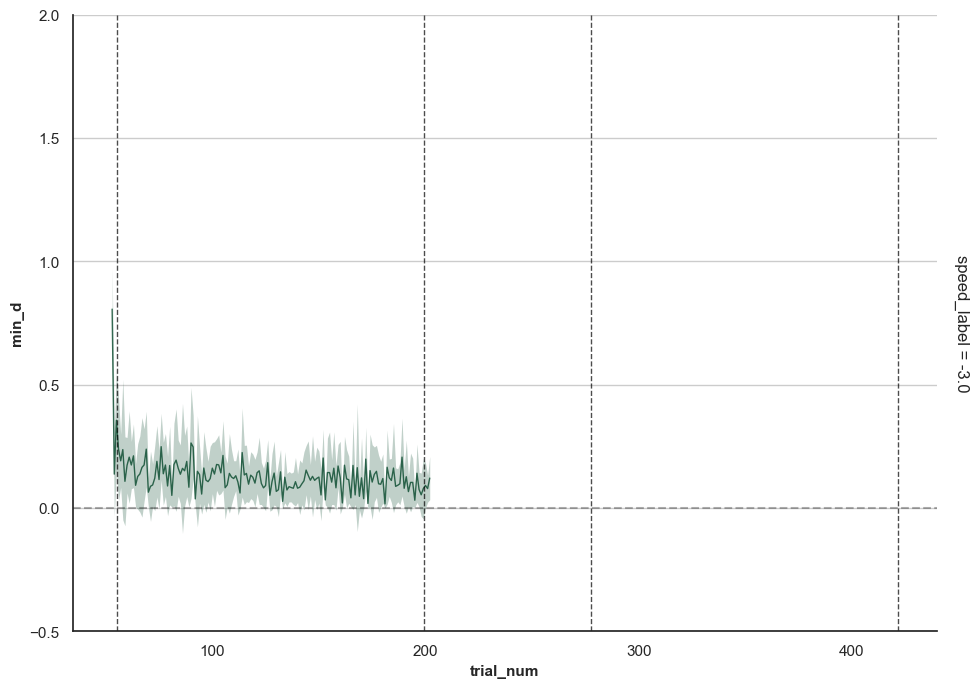

In [553]:
import pandas as pd
import numpy as np

# Load participant data
df_participant = pd.read_csv("C:/Users/jacob/water_current_MA/data/solution_space/df_L60_3_T1.csv")

# Assume df_hits is already loaded and contains valid solutions
# For example:
# df_wide = pd.read_csv("C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_L60.csv")
# df_long = df_wide.melt(id_vars=['Unnamed: 0'], var_name='angle', value_name='error_m')
# df_long.rename(columns={'Unnamed: 0': 'speed'}, inplace=True)
# df_long['is_hit'] = df_long['error_m'] < 0.10
# df_hits = df_long[df_long['is_hit']].copy()

# Calculate standard deviations using valid solutions (df_hits)
hit_speeds = df_hits['speed'].values
hit_thetas = df_hits['angle'].values

speed_std = np.std(hit_speeds)
theta_std = np.std(hit_thetas)

# Make hit and real speeds into np.array
real_speeds = df_participant['launch_Speed'].values
real_angles = df_participant['launch_angle'].values

# Make hit and real angles into np.array
hit_speeds = df_hits['speed'].values
hit_angles = df_hits['angle'].values

# Print the lengths of both arrays for debugging
print(f"Length of real speeds: {len(real_speeds)}")
print(f"Length of hit speeds: {len(hit_speeds)}")

print(f"Length of real thetas: {len(real_thetas)}")
print(f"Length of hit thetas: {len(hit_thetas)}")


# Broadcast and find differences, then normalize by variability of each parameter
speed_diffs = (real_speeds[:, np.newaxis] - hit_speeds[np.newaxis, :]) / speed_std
theta_diffs = (real_angles[:, np.newaxis] - hit_angles[np.newaxis, :]) / theta_std

d = np.sqrt((speed_diffs**2) + (theta_diffs**2))
min_d = np.min(d, axis=1)

# Now take min_d array and make it a column in df_participant for plotting
df_participant['min_d'] = min_d

# Plot the results
from src.plotting import plot_all_trials
plot_all_trials(df_participant,
                 col_col=None,
                 row_col='speed_label',
                 cond_col=None,
                 ppid_col='ppid_full',
                 target_col='target_x_label',
                 y_col='min_d', 
                 x_col='trial_num',
                 vertical_list=[55.5, 199.5, 277.5, 421.5],
                 hit_col='target_hit',
                 ref_range_col=None,
                 no_connect_col='phase',
                 context='notebook',
                 transition_col='water_speed_binary',
                 marker_size=0,
                 estimator='mean',
                 y_lim=(-0.5, 2),
                 show_zero_line=True
                )